# Credit-G Dataset EDA

In [1]:
import pandas as pd
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better-looking plots
sns.set_style("whitegrid")

In [2]:
data, meta = arff.loadarff('dataset_31_credit-g.arff')

In [3]:
df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except:
            pass

In [4]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


Column 'installment_commitment' has 4 unique values - treating as categorical
Column 'residence_since' has 4 unique values - treating as categorical
Column 'existing_credits' has 4 unique values - treating as categorical
Column 'num_dependents' has 2 unique values - treating as categorical


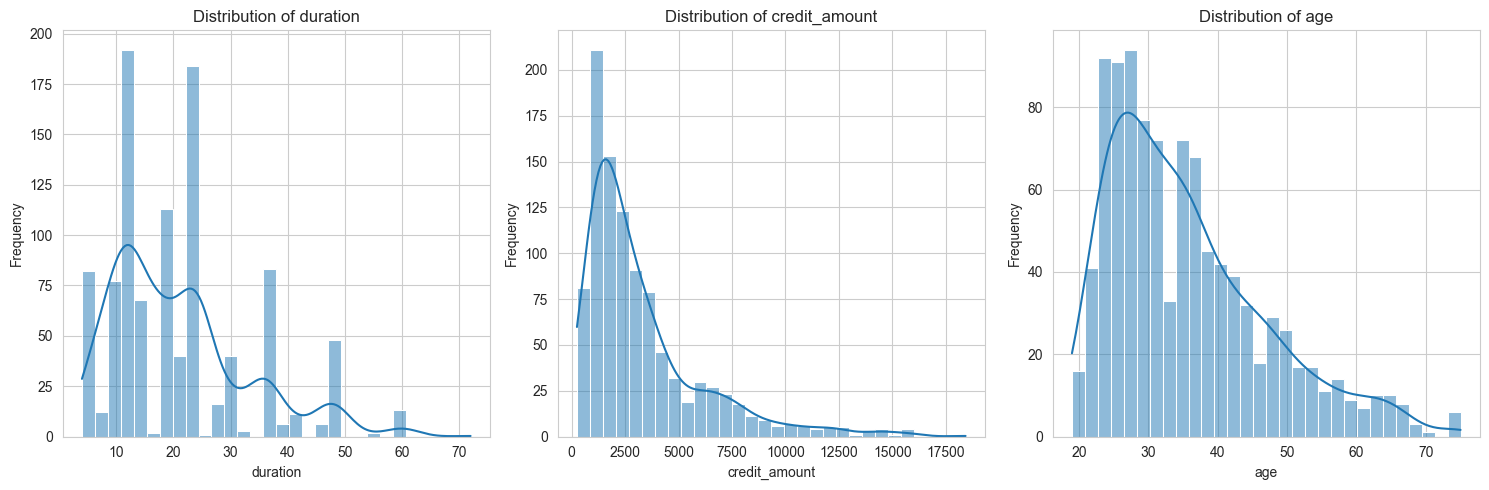

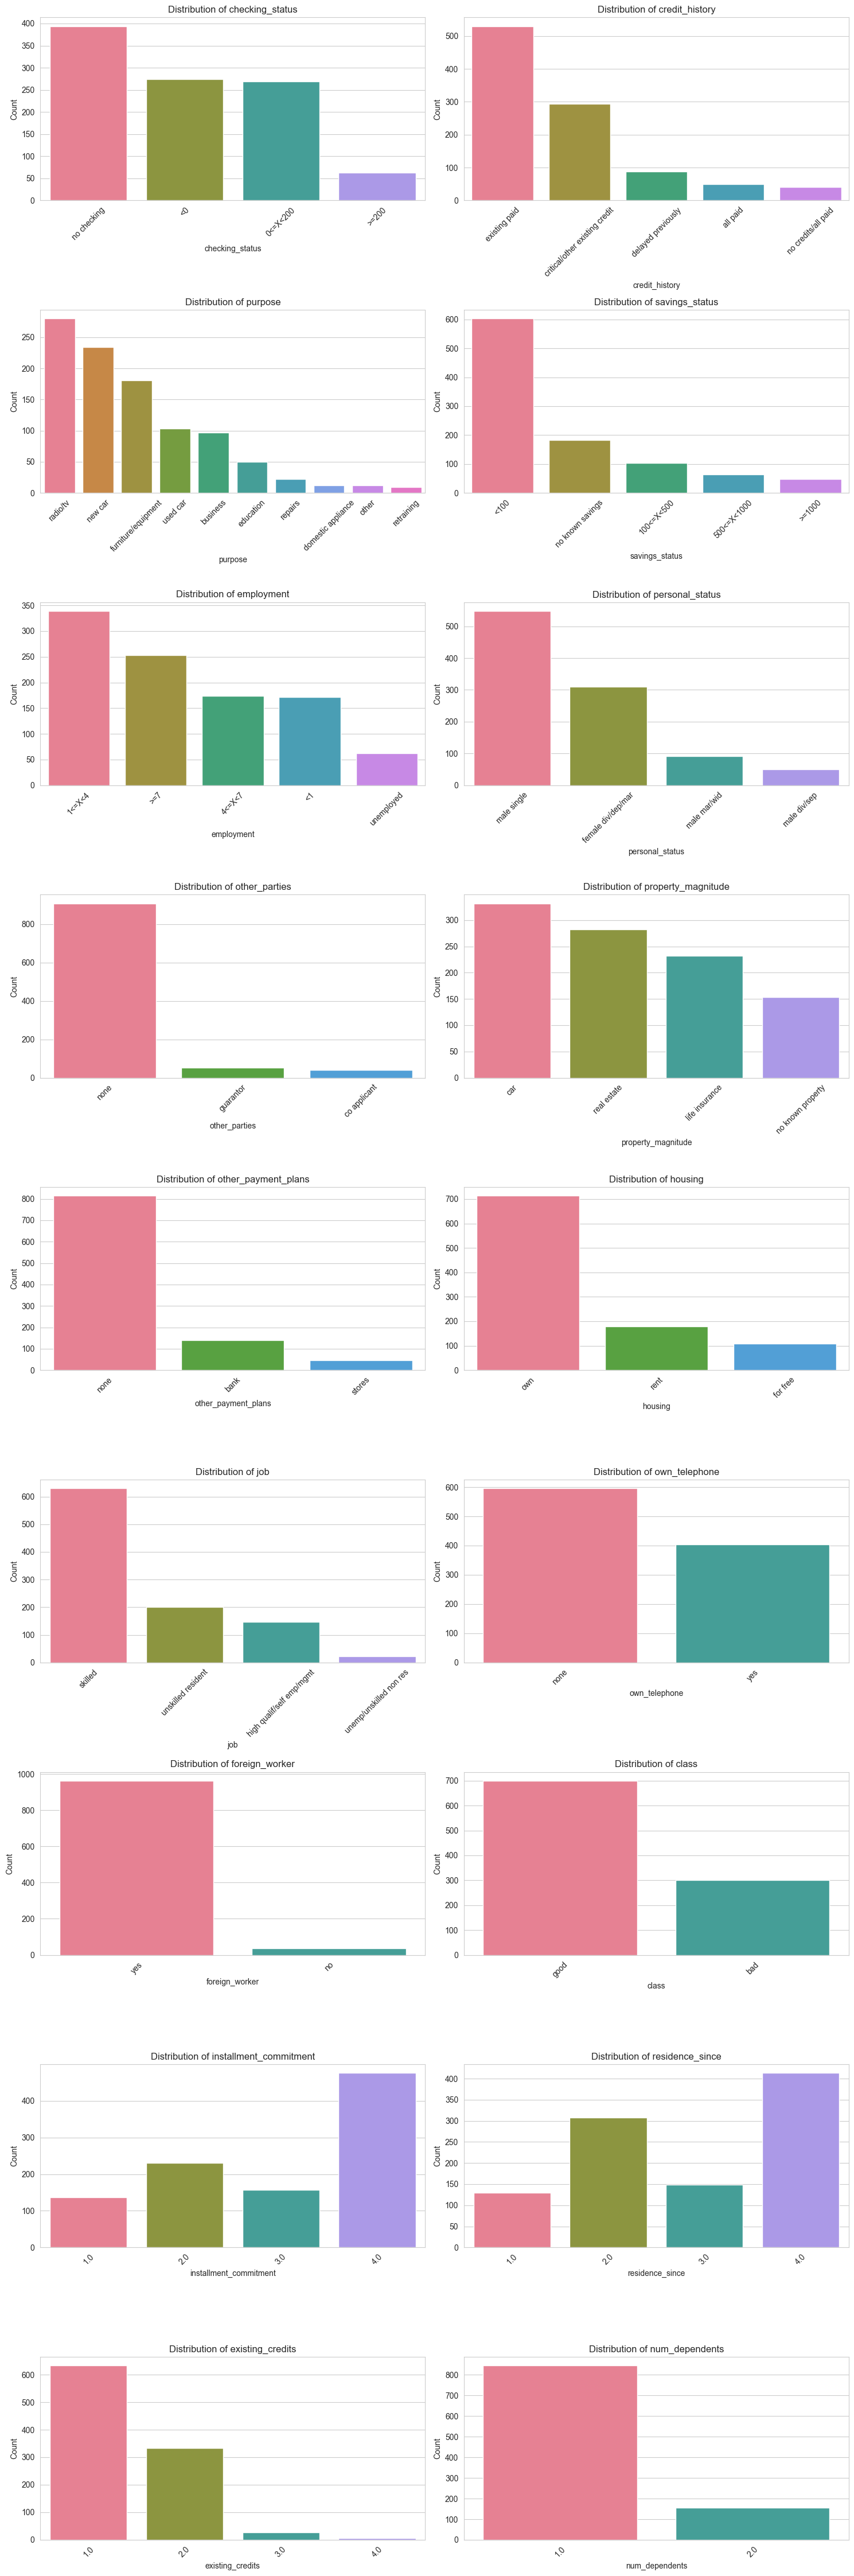

In [5]:
# Get numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Reclassify numeric columns with fewer than 5 unique values as categorical
truly_numeric_cols = []
for col in numeric_cols:
    if df[col].nunique() < 5:
        categorical_cols.append(col)
        print(f"Column '{col}' has {df[col].nunique()} unique values - treating as categorical")
    else:
        truly_numeric_cols.append(col)

numeric_cols = truly_numeric_cols

# Create distribution plots for numeric columns
if numeric_cols:
    n_numeric = len(numeric_cols)
    n_cols = 3
    n_rows = (n_numeric + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_numeric > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        sns.histplot(df[col], kde=True, ax=axes[idx], bins=30)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
    
    # Hide empty subplots
    for idx in range(n_numeric, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Create count plots for categorical columns with different colors
if categorical_cols:
    n_categorical = len(categorical_cols)
    n_cols = 2
    n_rows = (n_categorical + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_categorical > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        # Create a color palette with different colors for each bar
        colors = sns.color_palette("husl", len(value_counts))
        sns.barplot(x=value_counts.index, y=value_counts.values, hue=value_counts.index, 
                    ax=axes[idx], palette=colors, legend=False)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for idx in range(n_categorical, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()  